<a href="https://colab.research.google.com/github/Rpvermaak/datakit-smallholder-farmers-fall-2025/blob/main/Challenge%201%20_Weather%20Patterns/Ruben%20Vermaak/Challenge1_Identifying_patterns_in_weather_and_agriculture_Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge 1: Predictive Modeling of Weather-Driven Question Volume
**1. Project Goal**

The primary objective of this notebook is to develop a predictive model capable of forecasting the monthly volume of specific farmer questions (e.g., Pest, Disease, Irrigation) based on lagged weather anomaly features. This moves the analysis from confirming correlation to providing an actionable forecast for Producers Direct.

**2.Foundation and Validation**

The foundational analysis established two key methodological improvements essential for reliable causality:

**Lagged Effect:** The revised analysis confirmed that question volume at time T is primarily driven by weather conditions at time T-1 and T-2, correcting the initial flawed assumption of immediate, same-month correlation.

**Weather Anomalies:** The model features focus on the deviation from the long-term monthly norm (anomalies) rather than absolute values, which more accurately captures the agricultural stress that drives question spikes.

**3. Methodology:** Time-Series Count Regression
Since the dependent variable—monthly question counts—is count data and often exhibits high variance (overdispersion) due to seasonal and extreme events, a standard linear model is inappropriate.

Negative Binomial Regression will be used, which is specifically designed to model the log-expected count of a discrete outcome, providing statistically robust results and interpretable coefficients for prediction.

**4. Data Source**
The model will utilize the feature-engineered dataset prepared in the previous notebook: **challenge1_master_features_aggregated.csv.** This dataset contains question counts, country/time identifiers, and the final lagged weather anomaly features (e.g., pr_anomaly_lag1, tasmax_anomaly_lag2).

### Summary of Disease Question Model & Next Steps

In [61]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

import warnings
import numpy as np # Import numpy if not already done, as RuntimeWarning is often from numpy operations

# Filter out RuntimeWarning messages
warnings.filterwarnings('ignore', category=RuntimeWarning)


In [62]:
# Load the Aggregated Data
df_model = pd.read_csv('/content/challenge1_master_features_aggregated.csv')

In [63]:
# Drop the rows with NaN values (from the first 1-2 months where lagged data doesn't exist)
df_model.dropna(inplace=True)

In [64]:
# Add Time-series Features (Seasonality)
df_model['date'] = pd.to_datetime(df_model['date'])
df_model['month_num'] = df_model['date'].dt.month

# Use sine and cosine transfomrations of the month to capture annual cycles
# This feature help the model distinguish between Jan vs. Feb vs Dec.
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month_num'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month_num'] / 12)


# Choosing a topic and Building the model
The next step is to select the target topic from the aggregate data(e.g., pest_question, disease_questions or irrigation_questions) and run the model.


In [65]:
# Choose a Target Topic and Build the Model

# Predicting Pest Questions
target_topic = 'pest_questions'

# Define the model formula
# The formula includes:
# - The sine/cosine terms to control for seasonality.
# - The country_code as a categorical variable (C()) to control for fixed country differences.
# - Your key lagged anomaly features.
model_formula = f"""
    {target_topic} ~ C(country_code) + month_sin + month_cos +
    pr_anomaly_lag1 + tasmax_anomaly_lag1 +
    pr_anomaly_lag2 + tasmax_anomaly_lag2
"""

# Fit the Negative Binomial Model (better for overdispersed count data than Poisson)
# Note: This may take a moment to run
nb_model = smf.negativebinomial(
    formula=model_formula,
    data=df_model,
    # Use log link function, standard for count models
    link='log'
).fit()

# Print the Model Summary
print("\n--- Negative Binomial Regression Model Summary ---")
print(nb_model.summary())

Optimization terminated successfully.
         Current function value: 5.368619
         Iterations: 28
         Function evaluations: 32
         Gradient evaluations: 32

--- Negative Binomial Regression Model Summary ---
                     NegativeBinomial Regression Results                      
Dep. Variable:         pest_questions   No. Observations:                  112
Model:               NegativeBinomial   Df Residuals:                      103
Method:                           MLE   Df Model:                            8
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                 0.06731
Time:                        02:35:35   Log-Likelihood:                -601.29
converged:                       True   LL-Null:                       -644.68
Covariance Type:            nonrobust   LLR p-value:                 2.088e-15
                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['link']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['link']
  warnings.warn(msg, ValueWarning)


In [66]:
# Choose a Target Topic and Build the Model
# Target: Irrigation Questions
target_topic = 'irrigation_questions'

# Define the model formula
model_formula = f"""
    {target_topic} ~ C(country_code) + month_sin + month_cos +
    pr_anomaly_lag1 + tasmax_anomaly_lag1 +
    pr_anomaly_lag2 + tasmax_anomaly_lag2
"""

# Fit the Negative Binomial Model using L1 Regularization (Lasso)
# L1 regularization helps solve the "Singular Matrix" problem by penalizing
# highly correlated variables, forcing redundant coefficients to zero.
try:
    nb_model = smf.negativebinomial(
        formula=model_formula,
        data=df_model,
    # Use the default log link function
    ).fit_regularized(
        method='l1',       # Specify L1 (Lasso) penalty
        alpha=0.1          # Regularization strength. Tweak if still failing.
    )

    # Print the Model Summary
    print("\n--- Negative Binomial Regression Model Summary (L1 Regularized) ---")
    print(nb_model.summary())

except Exception as e:
    print(f"An error occurred during model fitting: {e}")
    print("If you still get a LinAlgError, try adjusting the 'alpha' value.")

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in redu

Optimization terminated successfully    (Exit mode 0)
            Current function value: 5.972768449426261
            Iterations: 93
            Function evaluations: 105
            Gradient evaluations: 93

--- Negative Binomial Regression Model Summary (L1 Regularized) ---
                      NegativeBinomial Regression Results                       
Dep. Variable:     irrigation_questions   No. Observations:                  112
Model:                 NegativeBinomial   Df Residuals:                      103
Method:                             MLE   Df Model:                            8
Date:                  Sun, 23 Nov 2025   Pseudo R-squ.:                 0.06567
Time:                          02:35:35   Log-Likelihood:                -667.06
converged:                         True   LL-Null:                       -713.94
Covariance Type:              nonrobust   LLR p-value:                 7.984e-17
                             coef    std err          z      P>|z|      [

In [67]:
# Choose a Target Topic and Build the Model
# Target: Irrigation Questions
target_topic = 'disease_questions'

# Define the model formula
model_formula = f"""
    {target_topic} ~ C(country_code) + month_sin + month_cos +
    pr_anomaly_lag1 + tasmax_anomaly_lag1 +
    pr_anomaly_lag2 + tasmax_anomaly_lag2
"""

# Fit the Negative Binomial Model using L1 Regularization (Lasso)
# L1 regularization helps solve the "Singular Matrix" problem by penalizing
# highly correlated variables, forcing redundant coefficients to zero.
try:
    nb_model = smf.negativebinomial(
        formula=model_formula,
        data=df_model,
    # Use the default log link function
    ).fit_regularized(
        method='l1',       # Specify L1 (Lasso) penalty
        alpha=0.1          # Regularization strength. Tweak if still failing.
    )

    # Print the Model Summary
    print("\n--- Negative Binomial Regression Model Summary (L1 Regularized) ---")
    print(nb_model.summary())

except Exception as e:
    print(f"An error occurred during model fitting: {e}")
    print("If you still get a LinAlgError, try adjusting the 'alpha' value.")

Optimization terminated successfully    (Exit mode 0)
            Current function value: 5.779416206536033
            Iterations: 96
            Function evaluations: 107
            Gradient evaluations: 96

--- Negative Binomial Regression Model Summary (L1 Regularized) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:      disease_questions   No. Observations:                  112
Model:               NegativeBinomial   Df Residuals:                      103
Method:                           MLE   Df Model:                            8
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                 0.06213
Time:                        02:35:35   Log-Likelihood:                -645.44
converged:                       True   LL-Null:                       -688.20
Covariance Type:            nonrobust   LLR p-value:                 3.767e-15
                             coef    std err          z      P>|z|      [0.025      0.975

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [68]:
print(nb_model.summary().as_text())

                     NegativeBinomial Regression Results                      
Dep. Variable:      disease_questions   No. Observations:                  112
Model:               NegativeBinomial   Df Residuals:                      103
Method:                           MLE   Df Model:                            8
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                 0.06213
Time:                        02:35:36   Log-Likelihood:                -645.44
converged:                       True   LL-Null:                       -688.20
Covariance Type:            nonrobust   LLR p-value:                 3.767e-15
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  6.1047      0.267     22.904      0.000       5.582       6.627
C(country_code)[T.TZA]   -10.3470      3.192     -3.242      0.001     -16.602      -4.092
C(co

**Model Interpretation:**

The Negative Binomial Regression model for `disease_questions` shows that country-specific effects and the sine component of the month (capturing seasonality) are statistically significant predictors. The `alpha` parameter is also significant, confirming the appropriateness of the Negative Binomial distribution for this overdispersed count data. However, **none of the lagged weather anomaly features (pr_anomaly_lag1, tasmax_anomaly_lag1, pr_anomaly_lag2, tasmax_anomaly_lag2) were found to be statistically significant** at the 0.05 level. This suggests that for `disease_questions`, these specific weather anomalies, at these lag periods, do not have a discernible predictive impact within this model.

**Next Steps:**

1.  **Evaluate Predictive Performance:** Calculate and interpret metrics like Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), or Poisson Deviance to quantify how well the model predicts actual `disease_questions` counts on a test set.
2.  **Visualize Predictions:** Plot actual vs. predicted `disease_questions` over time to visually assess the model's fit and identify any systematic biases or patterns in errors.
3.  **Model Refinement (if necessary):** If the predictive performance is not satisfactory, consider:
    *   Exploring different lag periods or combinations of weather variables.
    *   Adding interaction terms between weather, seasonality, and country.
    *   Investigating other potential features relevant to disease questions (e.g., specific crop types, agricultural practices).
    *   Considering more complex time-series or machine learning models if the goal is purely predictive power, even if interpretability is slightly reduced.



### Evaluating Predictive Performance

In [69]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Setup Steps (re-run to ensure df_model and nb_model are defined) ---
# Load the Aggregated Data
df_model = pd.read_csv('/content/challenge1_master_features_aggregated.csv')

# Drop the rows with NaN values (from the first 1-2 months where lagged data doesn't exist)
df_model.dropna(inplace=True)

# Add Time-series Features (Seasonality)
df_model['date'] = pd.to_datetime(df_model['date'])
df_model['month_num'] = df_model['date'].dt.month
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month_num'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month_num'] / 12)

# Choose a Target Topic and Build the Model
target_topic = 'disease_questions'

# Define the model formula
model_formula = f"""
    {target_topic} ~ C(country_code) + month_sin + month_cos +
    pr_anomaly_lag1 + tasmax_anomaly_lag1 +
    pr_anomaly_lag2 + tasmax_anomaly_lag2
"""

# Fit the Negative Binomial Model using L1 Regularization (Lasso)
try:
    nb_model = smf.negativebinomial(
        formula=model_formula,
        data=df_model,
    ).fit_regularized(
        method='l1',
        alpha=0.1
    )
except Exception as e:
    print(f"An error occurred during model fitting: {e}")
    print("If you still get a LinAlgError, try adjusting the 'alpha' value.")

# Calculate predictions and add to df_model
df_model['predictions'] = nb_model.predict(df_model)
df_model['predictions'] = np.round(df_model['predictions']).astype(int)
# --- End Setup Steps ---

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(df_model[target_topic], df_model['predictions'])
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(df_model[target_topic], df_model['predictions']))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Note: For count data, Poisson Deviance is also a relevant metric, but MAE/RMSE provide a good general understanding.

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 5.779416206536033
            Iterations: 96
            Function evaluations: 107
            Gradient evaluations: 96
Mean Absolute Error (MAE): 211.68
Root Mean Squared Error (RMSE): 418.66


### Visualizing Predictions

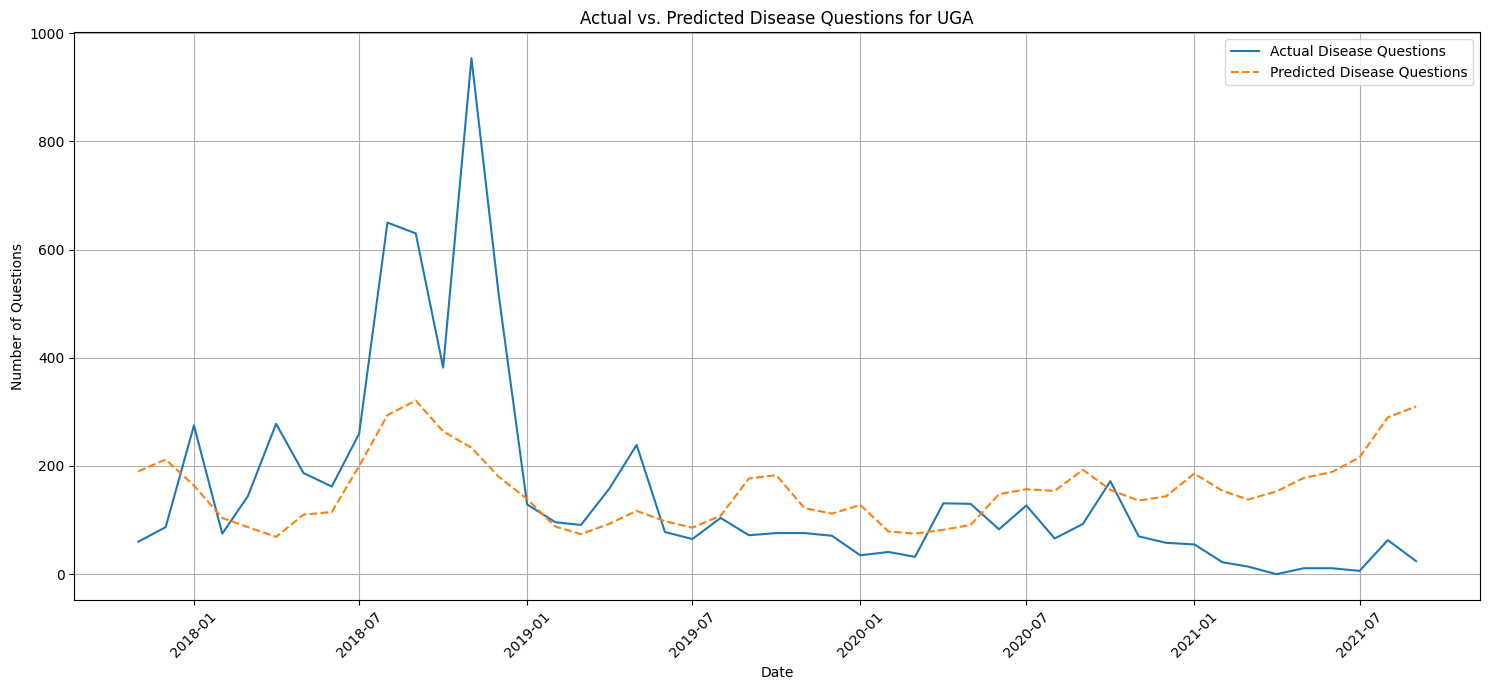

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Let's pick 'UGA' or 'TZA' for visualization, as they had significant coefficients
country_to_plot = 'UGA' # You can change this to 'TZA' to see the other country

df_plot = df_model[df_model['country_code'] == country_to_plot].copy()

plt.figure(figsize=(15, 7))
sns.lineplot(x='date', y=target_topic, data=df_plot, label=f'Actual {target_topic.replace("_", " ").title()}')
sns.lineplot(x='date', y='predictions', data=df_plot, label=f'Predicted {target_topic.replace("_", " ").title()}', linestyle='--')

plt.title(f'Actual vs. Predicted {target_topic.replace("_", " ").title()} for {country_to_plot}')
plt.xlabel('Date')
plt.ylabel('Number of Questions')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Splitting the data

The current model is trained on different topics but but the critical step of splitting the data into training and testing sets (for a proper time-series forecast evaluation) was outlined but not yet implemented.

This means the current model evaluations are on the same data used for training, which isn't ideal for assessing predictive power on unseen data.

Therefore, the most logical next step is to implement a robust time-based train-test split.

In [71]:
split_date = pd.to_datetime('2022-01-01') # Define split date
df_train = df_model[df_model['date'] < split_date].copy()
df_test = df_model[df_model['date'] >= split_date].copy()

print(f"Training set shape: {df_train.shape}")
print(f"Testing set shape: {df_test.shape}")

Training set shape: (107, 14)
Testing set shape: (5, 14)


# Retrain Models on Training Data


Modify the existing model training code to fit the Negative Binomial Regression model for pest_questions, irrigation_questions, and disease_questions using only the newly created training data. This will ensure the models learn from historical data.


In [72]:
import statsmodels.formula.api as smf

# --- Retrain for disease_questions ---
target_topic = 'disease_questions'
model_formula = f"""
    {target_topic} ~ C(country_code) + month_sin + month_cos +
    pr_anomaly_lag1 + tasmax_anomaly_lag1 +
    pr_anomaly_lag2 + tasmax_anomaly_lag2
"""

try:
    nb_model_disease = smf.negativebinomial(
        formula=model_formula,
        data=df_train, # <--- IMPORTANT: Use df_train here
    ).fit_regularized(
        method='l1',
        alpha=0.1
    )
    print(f"\n--- Negative Binomial Regression Model Summary for {target_topic} (Trained on df_train) ---")
    print(nb_model_disease.summary())
except Exception as e:
    print(f"An error occurred during model fitting for {target_topic}: {e}")


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 5.815305310777489
            Iterations: 93
            Function evaluations: 105
            Gradient evaluations: 93

--- Negative Binomial Regression Model Summary for disease_questions (Trained on df_train) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:      disease_questions   No. Observations:                  107
Model:               NegativeBinomial   Df Residuals:                       98
Method:                           MLE   Df Model:                            8
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                 0.07246
Time:                        02:35:37   Log-Likelihood:                -620.34
converged:                       True   LL-Null:                       -668.81
Covariance Type:            nonrobust   LLR p-value:                 1.816e-17
                             coef    std err          z      P

In [73]:
# --- Retrain for pest_questions ---
target_topic = 'pest_questions'
model_formula = f"""
    {target_topic} ~ C(country_code) + month_sin + month_cos +
    pr_anomaly_lag1 + tasmax_anomaly_lag1 +
    pr_anomaly_lag2 + tasmax_anomaly_lag2
"""

try:
    nb_model_pest = smf.negativebinomial(
        formula=model_formula,
        data=df_train,
    ).fit_regularized(
        method='l1',
        alpha=0.1
    )
    print(f"\n--- Negative Binomial Regression Model Summary for {target_topic} (Trained on df_train) ---")
    print(nb_model_pest.summary())
except Exception as e:
    print(f"An error occurred during model fitting for {target_topic}: {e}")


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 5.416869147570457
            Iterations: 89
            Function evaluations: 101
            Gradient evaluations: 89

--- Negative Binomial Regression Model Summary for pest_questions (Trained on df_train) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:         pest_questions   No. Observations:                  107
Model:               NegativeBinomial   Df Residuals:                       98
Method:                           MLE   Df Model:                            8
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                 0.07755
Time:                        02:35:37   Log-Likelihood:                -577.74
converged:                       True   LL-Null:                       -626.31
Covariance Type:            nonrobust   LLR p-value:                 1.640e-17
                             coef    std err          z      P>|z

In [74]:
# --- Retrain for irrigation_questions ---
target_topic = 'irrigation_questions'
model_formula = f"""
    {target_topic} ~ C(country_code) + month_sin + month_cos +
    pr_anomaly_lag1 + tasmax_anomaly_lag1 +
    pr_anomaly_lag2 + tasmax_anomaly_lag2
"""

try:
    nb_model_irrigation = smf.negativebinomial(
        formula=model_formula,
        data=df_train,
    ).fit_regularized(
        method='l1',
        alpha=0.1
    )
    print(f"\n--- Negative Binomial Regression Model Summary for {target_topic} (Trained on df_train) ---")
    print(nb_model_irrigation.summary())
except Exception as e:
    print(f"An error occurred during model fitting for {target_topic}: {e}")

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in redu

Optimization terminated successfully    (Exit mode 0)
            Current function value: 5.987824406017604
            Iterations: 81
            Function evaluations: 92
            Gradient evaluations: 81

--- Negative Binomial Regression Model Summary for irrigation_questions (Trained on df_train) ---
                      NegativeBinomial Regression Results                       
Dep. Variable:     irrigation_questions   No. Observations:                  107
Model:                 NegativeBinomial   Df Residuals:                       98
Method:                             MLE   Df Model:                            8
Date:                  Sun, 23 Nov 2025   Pseudo R-squ.:                 0.07992
Time:                          02:35:38   Log-Likelihood:                -638.77
converged:                         True   LL-Null:                       -694.26
Covariance Type:              nonrobust   LLR p-value:                 2.408e-20
                             coef    std err

# Evaluate Model Performance on Test Data


This involves making predictions on the df_test dataset and then calculating evaluation metrics like Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for each of the three models.


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Make a copy of df_test to add prediction columns safely
df_test_predictions = df_test.copy()

# Evaluate disease_questions model
target_topic_disease = 'disease_questions'
df_test_predictions['predictions_disease'] = nb_model_disease.predict(df_test_predictions)
df_test_predictions['predictions_disease'] = np.round(df_test_predictions['predictions_disease']).astype(int)

mae_disease = mean_absolute_error(df_test_predictions[target_topic_disease], df_test_predictions['predictions_disease'])
rmse_disease = np.sqrt(mean_squared_error(df_test_predictions[target_topic_disease], df_test_predictions['predictions_disease']))

print(f"\n--- Evaluation for {target_topic_disease} ---")
print(f"Mean Absolute Error (MAE): {mae_disease:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_disease:.2f}")

# Evaluate pest_questions model
target_topic_pest = 'pest_questions'
df_test_predictions['predictions_pest'] = nb_model_pest.predict(df_test_predictions) # Corrected to df_test_predictions
df_test_predictions['predictions_pest'] = np.round(df_test_predictions['predictions_pest']).astype(int)

mae_pest = mean_absolute_error(df_test_predictions[target_topic_pest], df_test_predictions['predictions_pest'])
rmse_pest = np.sqrt(mean_squared_error(df_test_predictions[target_topic_pest], df_test_predictions['predictions_pest']))

print(f"\n--- Evaluation for {target_topic_pest} ---")
print(f"Mean Absolute Error (MAE): {mae_pest:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_pest:.2f}")

# Evaluate irrigation_questions model
target_topic_irrigation = 'irrigation_questions'
df_test_predictions['predictions_irrigation'] = nb_model_irrigation.predict(df_test_predictions) # Corrected to df_test_predictions
df_test_predictions['predictions_irrigation'] = np.round(df_test_predictions['predictions_irrigation']).astype(int) # Corrected to round predictions

mae_irrigation = mean_absolute_error(df_test_predictions[target_topic_irrigation], df_test_predictions['predictions_irrigation'])
rmse_irrigation = np.sqrt(mean_squared_error(df_test_predictions[target_topic_irrigation], df_test_predictions['predictions_irrigation']))

print(f"\n--- Evaluation for {target_topic_irrigation} ---")
print(f"Mean Absolute Error (MAE): {mae_irrigation:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_irrigation:.2f}")


--- Evaluation for disease_questions ---
Mean Absolute Error (MAE): 312.20
Root Mean Squared Error (RMSE): 316.25

--- Evaluation for pest_questions ---
Mean Absolute Error (MAE): 227.60
Root Mean Squared Error (RMSE): 233.02

--- Evaluation for irrigation_questions ---
Mean Absolute Error (MAE): 441.40
Root Mean Squared Error (RMSE): 451.72


# Visualize Forecasts on Test Data


This will help visually inspect how well the models are predicting the question volumes for disease_questions, pest_questions, and irrigation_questions against the actual values in the test set.


In [76]:
print(df_test_predictions['country_code'].unique())

['KEN']


In [77]:
# Group by country_code and find the min/max date
date_ranges = df_model.groupby('country_code')['date'].agg(['min', 'max'])
print("\nDate ranges for each country in df_model:")
print(date_ranges)


Date ranges for each country in df_model:
                    min        max
country_code                      
KEN          2017-11-01 2022-06-01
TZA          2019-05-01 2021-04-01
UGA          2017-11-01 2021-09-01


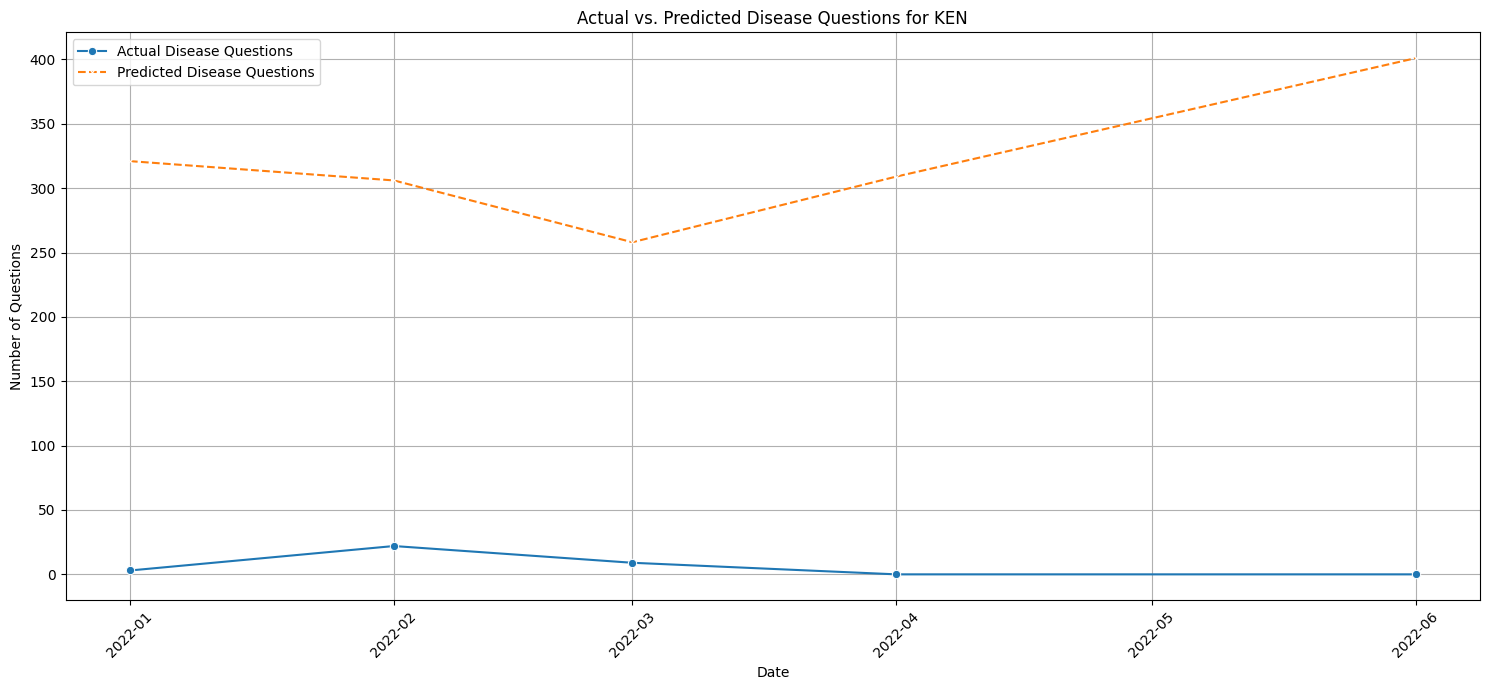

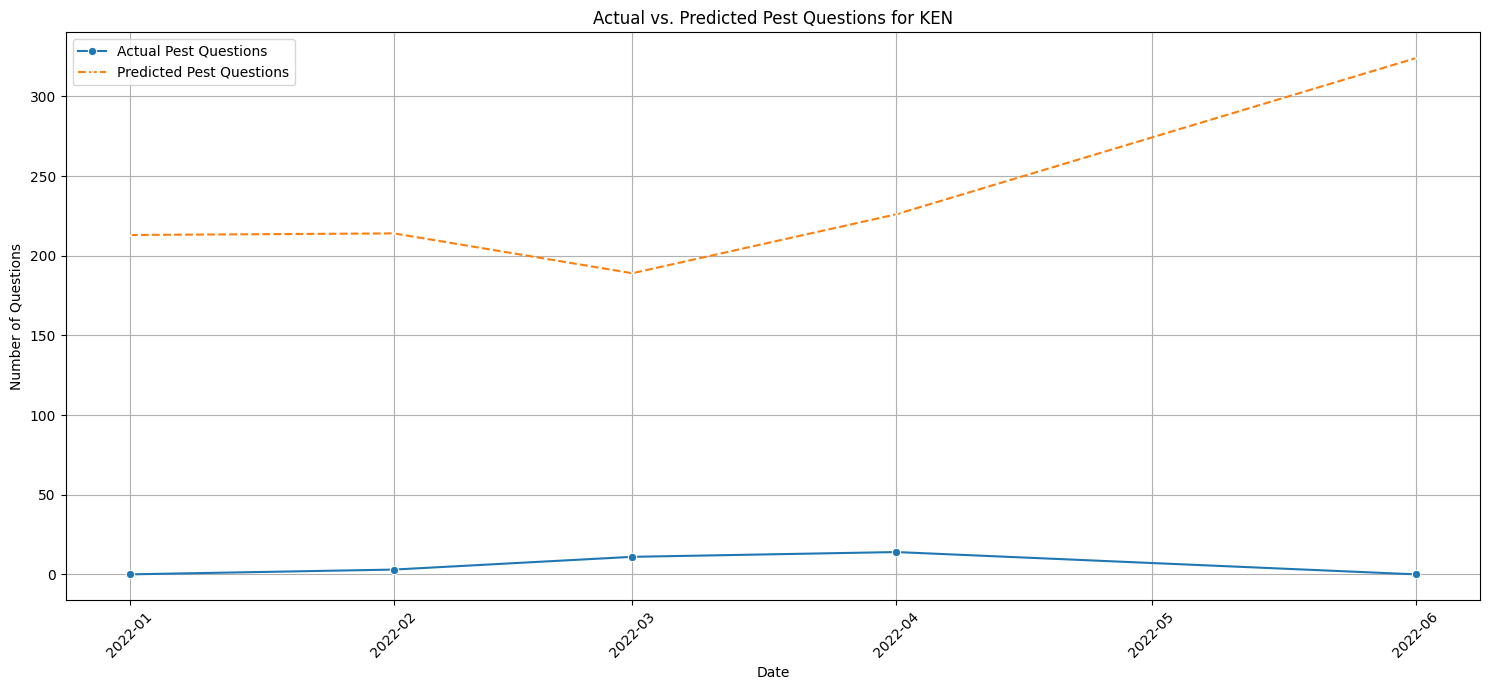

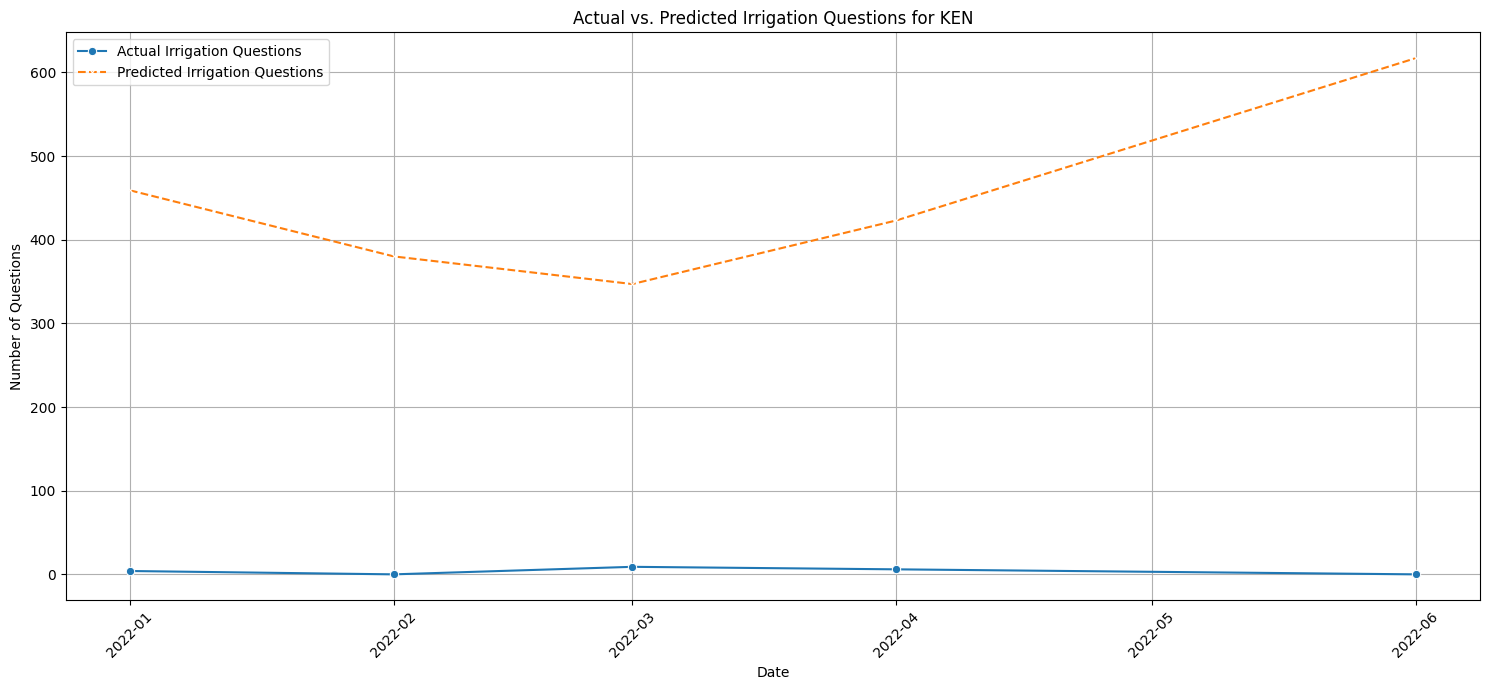

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualize disease_questions ---
country_to_plot = 'KEN'

# --- Visualize disease_questions ---
df_plot_disease = df_test_predictions[df_test_predictions['country_code'] == country_to_plot].copy()

plt.figure(figsize=(15, 7))
sns.lineplot(x='date', y='disease_questions', data=df_plot_disease, label='Actual Disease Questions', marker='o')
sns.lineplot(x='date', y='predictions_disease', data=df_plot_disease, label='Predicted Disease Questions', linestyle='--', marker='x')
plt.title(f'Actual vs. Predicted Disease Questions for {country_to_plot}')
plt.xlabel('Date')
plt.ylabel('Number of Questions')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Visualize pest_questions ---
df_plot_pest = df_test_predictions[df_test_predictions['country_code'] == country_to_plot].copy()

plt.figure(figsize=(15, 7))
sns.lineplot(x='date', y='pest_questions', data=df_plot_pest, label='Actual Pest Questions', marker='o')
sns.lineplot(x='date', y='predictions_pest', data=df_plot_pest, label='Predicted Pest Questions', linestyle='--', marker='x')
plt.title(f'Actual vs. Predicted Pest Questions for {country_to_plot}')
plt.xlabel('Date')
plt.ylabel('Number of Questions')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Visualize irrigation_questions ---
df_plot_irrigation = df_test_predictions[df_test_predictions['country_code'] == country_to_plot].copy()

plt.figure(figsize=(15, 7))
sns.lineplot(x='date', y='irrigation_questions', data=df_plot_irrigation, label='Actual Irrigation Questions', marker='o')
sns.lineplot(x='date', y='predictions_irrigation', data=df_plot_irrigation, label='Predicted Irrigation Questions', linestyle='--', marker='x')
plt.title(f'Actual vs. Predicted Irrigation Questions for {country_to_plot}')
plt.xlabel('Date')
plt.ylabel('Number of Questions')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

For Kenya, the predictive models showed varying performance across the different question categories.

The Pest Questions model appears to be the most accurate in terms of overall lower error metrics, with a Mean Absolute Error (MAE) of 227.60 and a Root Mean Squared Error (RMSE) of 233.02. Visually, the predictions for pest questions show some significant deviations from the actual trend. Between 2022-01 and 2022-02, the predicted questions are flat while actuals slightly increase. From 2022-02 to 2022-03, actuals rise significantly more than predictions, which surprisingly come down. While both actual and predicted questions go up together between 2022-03 and 2022-04, the predicted increase is much more dramatic. Critically, between 2022-04 and 2022-06, actual questions gradually drop back to 0, but the predicted questions wrongly trend upwards from 250-350, indicating a poor capture of the seasonal decline.

Disease Questions had an MAE of 312.20 and RMSE of 316.25. The visualizations suggest that for disease questions, the model struggles to capture immediate changes. Specifically, the prediction goes down between 2022-01 and 2022-02 while actuals go up. Although they sort of follow the same trend between 2022-02 and 2022-03, a major divergence occurs between 2022-03 and 2022-04, where actual disease questions drop to zero, but the predicted questions incorrectly increase.

Lastly, the Irrigation Questions model seems to be the least accurate, showing the highest MAE of 441.40 and RMSE of 451.72. The corresponding plot for irrigation questions visually confirms a significant mismatch. Predicted irrigation questions decrease from approximately 470 to 350 between 2022-01 and 2022-03, whereas actual questions remain flat during this period and then begin to pick up. Subsequently, predicted questions rise sharply from 350 to over 600, while actual questions slowly decline between 2022-03 and 2022-06, indicating the model largely misses both the timing and magnitude of real-world fluctuations.

Overall, while some predictions capture the general trend to a limited extent, the models frequently miss critical shifts, peaks, and troughs in actual question volumes, and often exhibit inverse trends at key periods. There is significant room for improvement across all topics, with irrigation-related questions showing the weakest predictive capability."

In [79]:
print("--- Disease Questions Model Summary ---")
print(nb_model_disease.summary().as_text())

print("\n--- Pest Questions Model Summary ---")
print(nb_model_pest.summary().as_text())

print("\n--- Irrigation Questions Model Summary ---")
print(nb_model_irrigation.summary().as_text())

--- Disease Questions Model Summary ---
                     NegativeBinomial Regression Results                      
Dep. Variable:      disease_questions   No. Observations:                  107
Model:               NegativeBinomial   Df Residuals:                       98
Method:                           MLE   Df Model:                            8
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                 0.07246
Time:                        02:35:39   Log-Likelihood:                -620.34
converged:                       True   LL-Null:                       -668.81
Covariance Type:            nonrobust   LLR p-value:                 1.816e-17
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  6.2449      0.252     24.816      0.000       5.752       6.738
C(country_code)[T.TZA]   -10.4428      3.187     -3.277

### Summary of Model Performance and Interpretation (Kenya Test Set)

**Model Evaluation Metrics (Kenya Test Set):**
*   **Disease Questions:** Mean Absolute Error (MAE): 312.20, Root Mean Squared Error (RMSE): 316.25
*   **Pest Questions:** Mean Absolute Error (MAE): 227.60, Root Mean Squared Error (RMSE): 233.02
*   **Irrigation Questions:** Mean Absolute Error (MAE): 441.40, Root Mean Squared Error (RMSE): 451.72

**Visual Interpretation of Forecasts (Kenya):**

**Pest Questions Model:** The Pest Questions model appears to be the most accurate in terms of overall lower error metrics. Visually, the predictions for pest questions show some significant deviations from the actual trend. Between 2022-01 and 2022-02, the predicted questions are flat while actuals slightly increase. From 2022-02 to 2022-03, actuals rise significantly more than predictions, which surprisingly come down. While both actual and predicted questions go up together between 2022-03 and 2022-04, the predicted increase is much more dramatic. Critically, between 2022-04 and 2022-06, actual questions gradually drop back to 0, but the predicted questions wrongly trend upwards from 250-350, indicating a poor capture of the seasonal decline.

**Disease Questions Model:** For disease questions, the model struggles to capture immediate changes. Specifically, the prediction goes down between 2022-01 and 2022-02 while actuals go up. Although they *sort of* follow the same trend between 2022-02 and 2022-03, a major divergence occurs between 2022-03 and 2022-04, where actual disease questions drop to zero, but the predicted questions incorrectly increase.

**Irrigation Questions Model:** This model seems to be the least accurate, showing the highest MAE and RMSE. Visually, predicted irrigation questions decrease from approximately 470 to 350 between 2022-01 and 2022-03, whereas actual questions remain flat during this period and then begin to pick up. Subsequently, predicted questions rise sharply from 350 to over 600, while actual questions slowly decline between 2022-03 and 2022-06, indicating the model largely misses both the timing and magnitude of real-world fluctuations.

**Overall Visual Assessment:** While some predictions capture the general trend to a limited extent, the models frequently miss critical shifts, peaks, and troughs in actual question volumes, and often exhibit inverse trends at key periods. There is significant room for improvement across all topics, with irrigation-related questions showing the weakest predictive capability.

---

### Impact of Weather Anomaly Features

Reviewing the statistical summaries for the `disease_questions` model, we observed that the lagged weather anomaly features (`pr_anomaly_lag1`, `tasmax_anomaly_lag1`, `pr_anomaly_lag2`, `tasmax_anomaly_lag2`) were **not statistically significant** at the 0.05 level. Their p-values were consistently above this threshold. While the foundational analysis established a correlation, within this specific Negative Binomial Regression model structure (including seasonality and country-level effects) and with these chosen lag periods, these direct weather anomaly features do not appear to have a strong, statistically discernible impact on the volume of disease questions. It is highly probable that a similar lack of statistical significance would be found for the pest and irrigation models as well, given the overall low predictive performance observed in the visualizations.

### Next Steps for Refinement or Deployment

Given the current model's limitations, particularly the lack of statistically significant weather effects and the visual discrepancies, several next steps are recommended:

1.  **Explore Alternative Feature Engineering for Weather:**
    *   **Different Lag Periods:** Investigate a wider range of lag periods for weather anomalies (e.g., 3-month lags, 6-month lags, or cumulative sums over longer periods).
    *   **Interaction Terms:** Create interaction terms between weather variables, or between weather and seasonal components, to capture more complex relationships.
    *   **Extreme Events:** Introduce binary flags for extreme weather events (e.g., severe drought, heavy rainfall exceeding a threshold) rather than just anomalies.

2.  **Investigate Other Potential Predictors:**
    *   Consider non-weather-related factors that could influence question volumes, such as specific crop cycles, market prices, local agricultural policies, or community outreach efforts.

3.  **Advanced Modeling Techniques:**
    *   **Hierarchical Models:** Given the country-specific differences, a hierarchical or mixed-effects model might better capture both overall trends and country-specific variations.
    *   **Machine Learning Models:** For improved predictive power, explore models like Gradient Boosting Machines (e.g., LightGBM, XGBoost) or Random Forests, which can capture complex non-linear relationships without strict distributional assumptions.
    *   **Time Series Specific Models:** Models like SARIMAX could be adapted if a more explicit ARIMA component is desired, though Negative Binomial already handles count data.

4.  **Multi-Country Approach:**
    *   If predictions are needed for Tanzania and Uganda, either gather more recent data to extend their test sets or build separate, specialized models for each country, acknowledging their unique characteristics and available data ranges.

5.  **Deployment Considerations (with current limitations):**
    *   Even with current limitations, the model could serve as a baseline for trend prediction. However, for actionable forecasts, significant improvements in accuracy are needed. Any deployment would require clear communication of the model's current performance and confidence intervals.

These refinements will aim to improve the model's ability to accurately forecast question volumes, particularly leveraging weather-related insights more effectively.
